# Introducción al clustering

In [59]:
import warnings
warnings.filterwarnings('ignore')

In [60]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import single, cophenet
from scipy.spatial.distance import pdist, squareform

In [61]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


# Importación de un modelo con datos de tarjetas de crédito (cc general.csv).

In [62]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt



path_filename = "CC_GENERAL.csv"
path_file =  os.path.join('', path_filename)

df = pd.read_csv(path_file, sep=',')


### Exploratory data analysis

In [63]:
df.sample()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
1743,C11802,11.25,0.64,137.84,137.84,0.00,0.00,0.17,0.17,0.00,0.00,0,3,10000.00,234.44,101.42,0.17,12


In [64]:
df.shape

(8950, 18)

In [65]:
df.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [67]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.00,1564.47,2081.53,0.00,128.28,873.39,2054.14,19043.14
BALANCE_FREQUENCY,8950.00,0.88,0.24,0.00,0.89,1.00,1.00,1.00
PURCHASES,8950.00,1003.20,2136.63,0.00,39.63,361.28,1110.13,49039.57
ONEOFF_PURCHASES,8950.00,592.44,1659.89,0.00,0.00,38.00,577.40,40761.25
INSTALLMENTS_PURCHASES,8950.00,411.07,904.34,0.00,0.00,89.00,468.64,22500.00
CASH_ADVANCE,8950.00,978.87,2097.16,0.00,0.00,0.00,1113.82,47137.21
PURCHASES_FREQUENCY,8950.00,0.49,0.40,0.00,0.08,0.50,0.92,1.00
ONEOFF_PURCHASES_FREQUENCY,8950.00,0.20,0.30,0.00,0.00,0.08,0.30,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,8950.00,0.36,0.40,0.00,0.00,0.17,0.75,1.00
CASH_ADVANCE_FREQUENCY,8950.00,0.14,0.20,0.00,0.00,0.00,0.22,1.50


In [68]:
df[df==0].count() / df.count()

CUST_ID                            0.00
BALANCE                            0.01
BALANCE_FREQUENCY                  0.01
PURCHASES                          0.23
ONEOFF_PURCHASES                   0.48
INSTALLMENTS_PURCHASES             0.44
CASH_ADVANCE                       0.52
PURCHASES_FREQUENCY                0.23
ONEOFF_PURCHASES_FREQUENCY         0.48
PURCHASES_INSTALLMENTS_FREQUENCY   0.44
CASH_ADVANCE_FREQUENCY             0.52
CASH_ADVANCE_TRX                   0.52
PURCHASES_TRX                      0.23
CREDIT_LIMIT                       0.00
PAYMENTS                           0.03
MINIMUM_PAYMENTS                   0.00
PRC_FULL_PAYMENT                   0.66
TENURE                             0.00
dtype: float64

In [69]:
df.head(4)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.90,0.82,95.40,0.00,95.40,0.00,0.17,0.00,0.08,0.00,0,2,1000.00,201.80,139.51,0.00,12
1,C10002,3202.47,0.91,0.00,0.00,0.00,6442.95,0.00,0.00,0.00,0.25,4,0,7000.00,4103.03,1072.34,0.22,12
2,C10003,2495.15,1.00,773.17,773.17,0.00,0.00,1.00,1.00,0.00,0.00,0,12,7500.00,622.07,627.28,0.00,12
3,C10004,1666.67,0.64,1499.00,1499.00,0.00,205.79,0.08,0.08,0.00,0.08,1,1,7500.00,0.00,NaN,0.00,12


In [70]:
df.nunique()

CUST_ID                             8950
BALANCE                             8871
BALANCE_FREQUENCY                     43
PURCHASES                           6203
ONEOFF_PURCHASES                    4014
INSTALLMENTS_PURCHASES              4452
CASH_ADVANCE                        4323
PURCHASES_FREQUENCY                   47
ONEOFF_PURCHASES_FREQUENCY            47
PURCHASES_INSTALLMENTS_FREQUENCY      47
CASH_ADVANCE_FREQUENCY                54
CASH_ADVANCE_TRX                      65
PURCHASES_TRX                        173
CREDIT_LIMIT                         205
PAYMENTS                            8711
MINIMUM_PAYMENTS                    8636
PRC_FULL_PAYMENT                      47
TENURE                                 7
dtype: int64

In [71]:
print('Existen',df.isnull().sum().sum(),'valores no definidos')

Existen 314 valores no definidos


In [72]:
print(df.columns[df.isnull().any()])

Index(['CREDIT_LIMIT', 'MINIMUM_PAYMENTS'], dtype='object')


In [73]:
df[df.columns[df.isnull().any()]].isnull().sum()

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

In [74]:
df[df.columns[df.isnull().any()]].isnull().sum()*100/df.shape[0]

CREDIT_LIMIT       0.01
MINIMUM_PAYMENTS   3.50
dtype: float64

In [75]:
print('Duplicate records:')
print(df[df.duplicated()])

Duplicate records:
Empty DataFrame
Columns: [CUST_ID, BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PURCHASES_TRX, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS, PRC_FULL_PAYMENT, TENURE]
Index: []


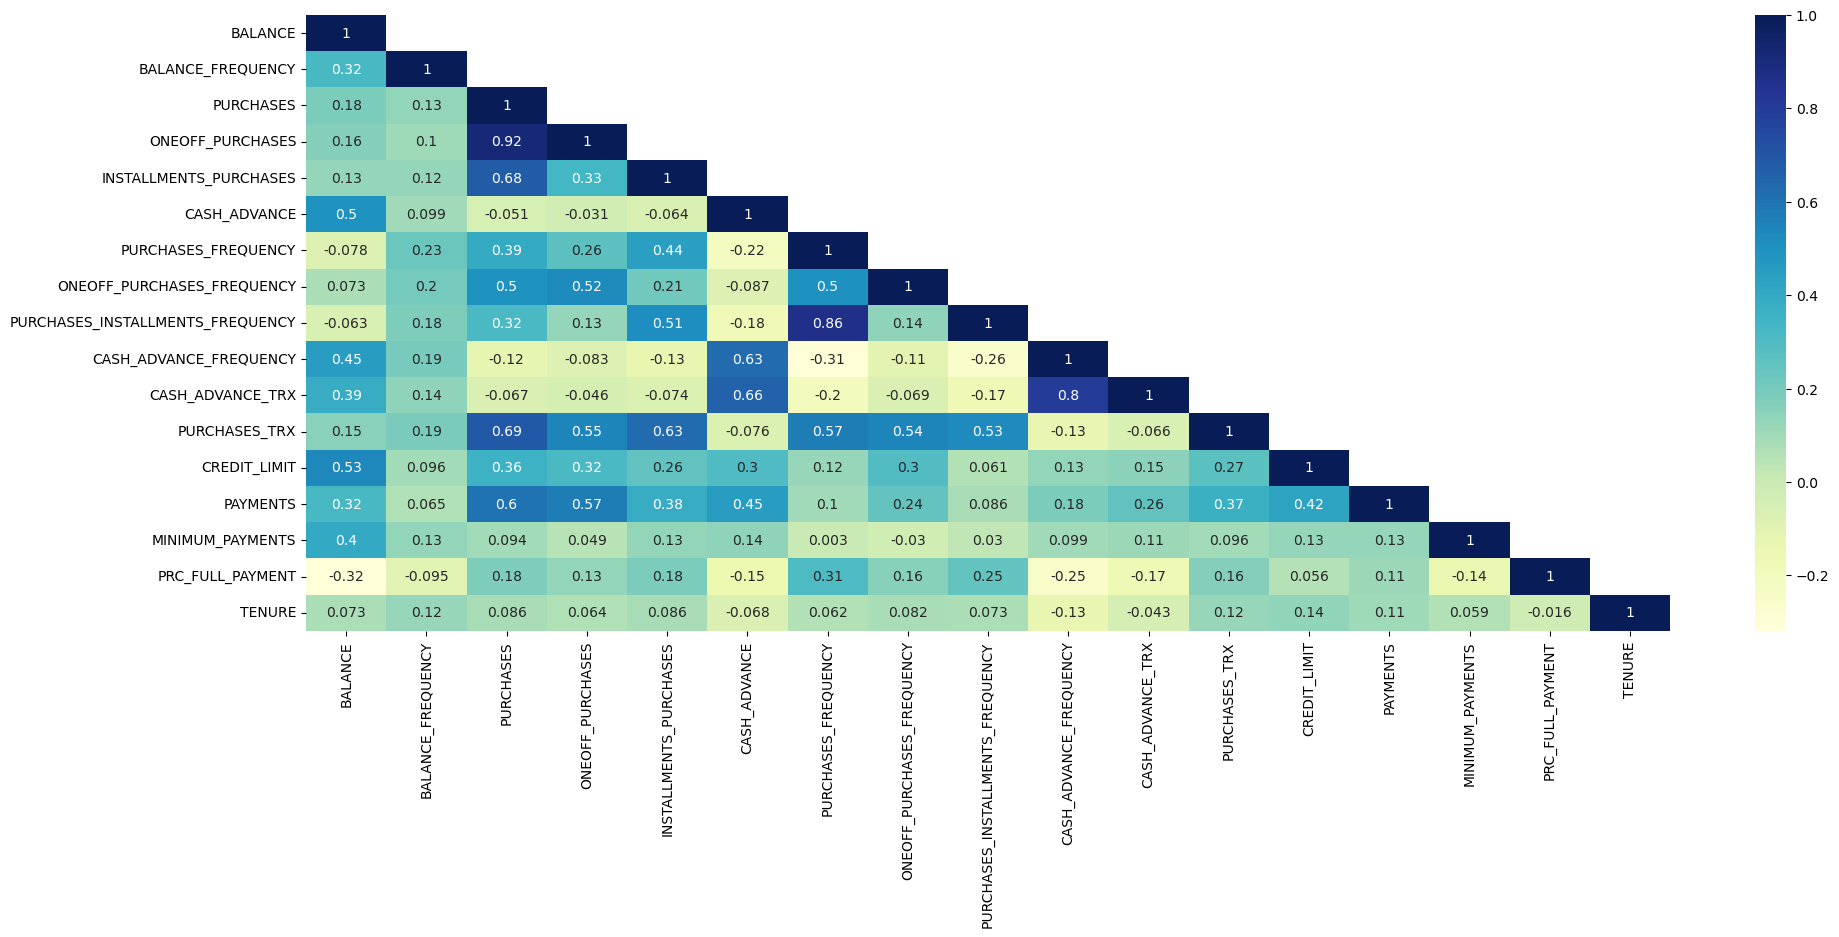

In [76]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,8))
corr_df = corr = df.corr(numeric_only=True,method='pearson')
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='YlGnBu',annot=True)

In [77]:
pd.options.display.float_format = '{:.2f}'.format

In [78]:
numerics = ['int16', 'int32','int64','float64']
df.select_dtypes(include=numerics).sample(5)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3096,2311.16,1.00,318.85,0.00,318.85,3541.75,0.75,0.00,0.75,0.33,4,9,5000.00,526.71,735.30,0.00,12
3746,1253.72,1.00,87.40,87.40,0.00,0.00,0.08,0.08,0.00,0.00,0,2,6500.00,303.38,307.92,0.00,12
3984,8121.78,1.00,231.14,52.44,178.70,2992.21,1.00,0.08,1.00,0.25,18,14,12000.00,2143.67,2870.33,0.00,12
4237,2092.97,1.00,0.00,0.00,0.00,135.26,0.00,0.00,0.00,0.33,2,0,2500.00,275.68,217.43,0.00,6
894,233.69,1.00,1772.55,1352.55,420.00,0.00,1.00,1.00,0.75,0.00,0,29,1200.00,764.82,227.73,0.08,12


In [79]:
cols_num = df.columns[[np.issubdtype(dt,np.number) for dt in df.dtypes]]

In [80]:
print(cols_num)
print(len(cols_num))

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')
17


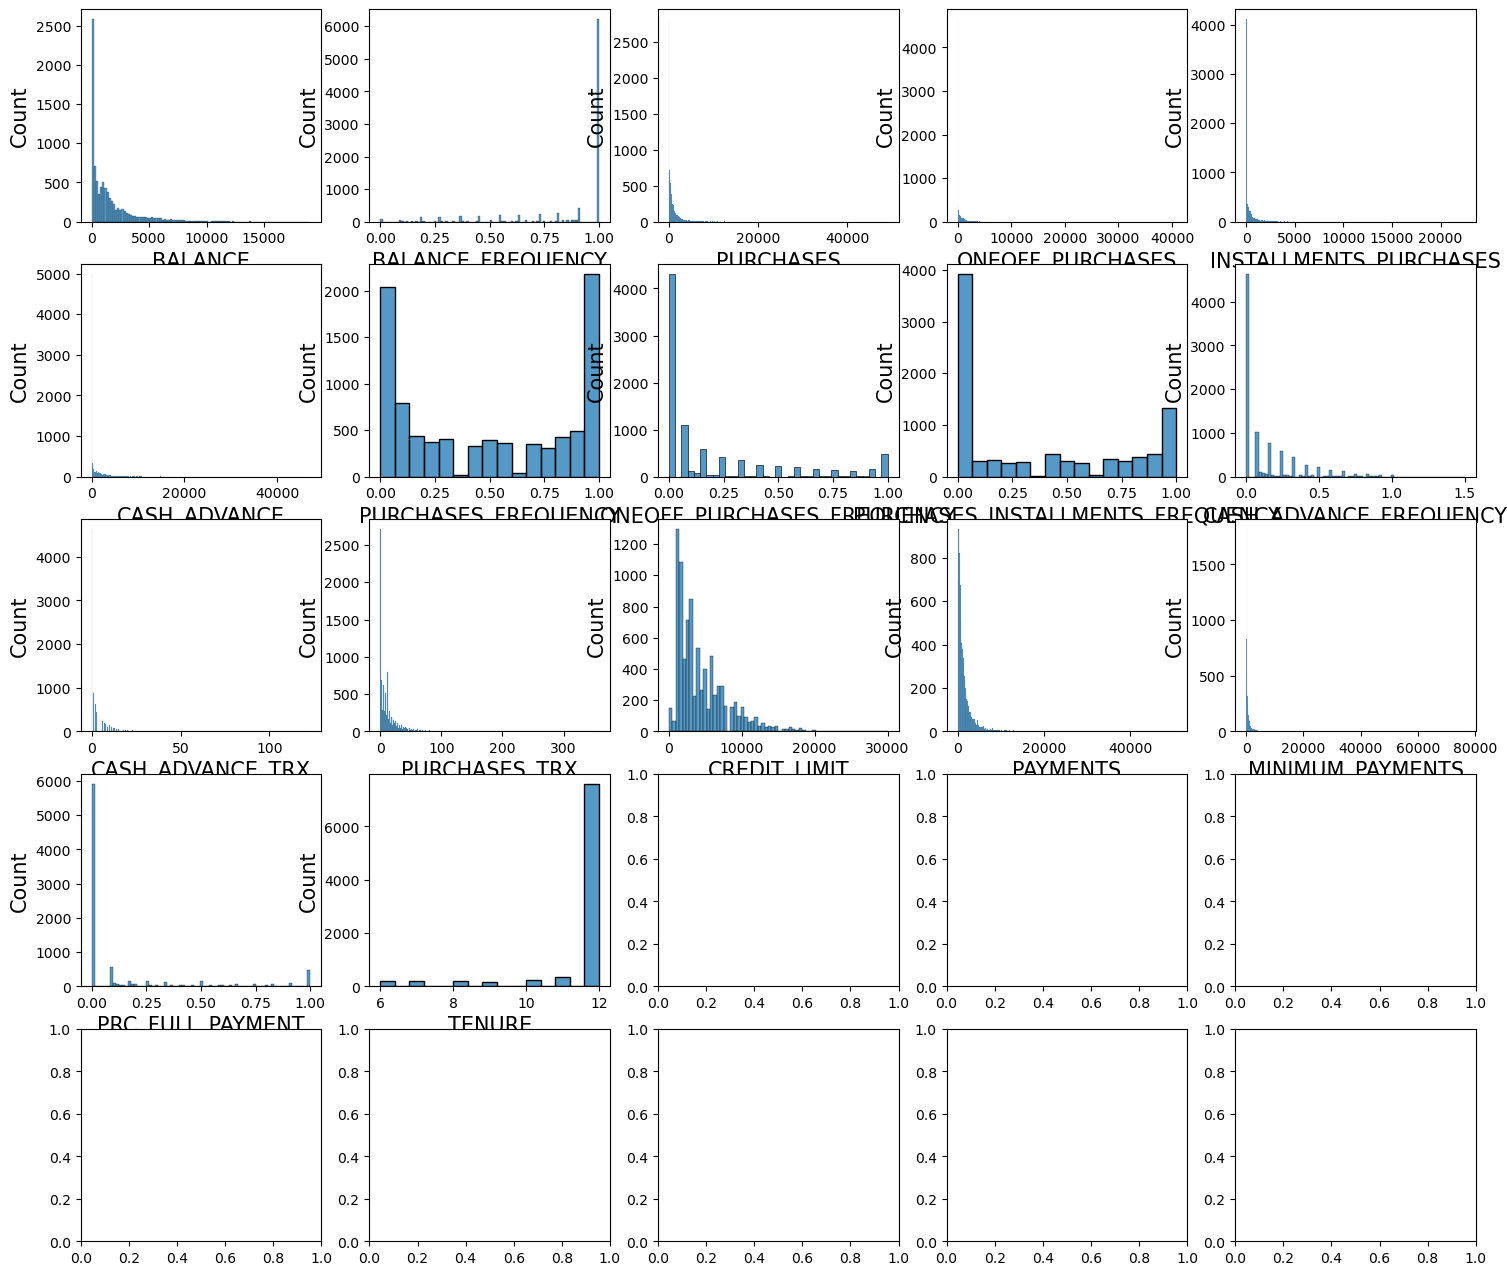

In [81]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//5,i%5],kde=False)

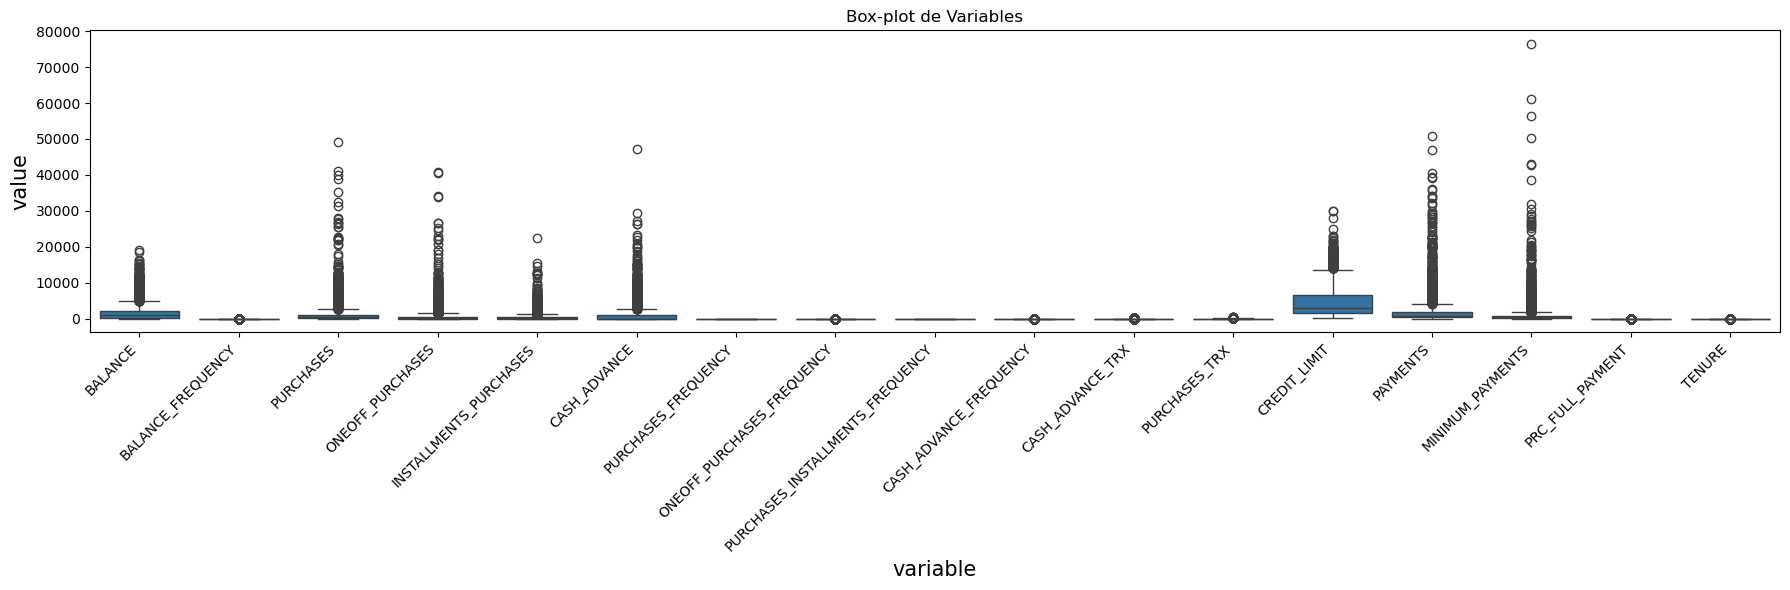

In [82]:
plt.figure(figsize=(18,6))
sns.boxplot(x='variable',y='value',data=pd.melt(df[cols_num])).set_title('Box-plot de Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


In [93]:
df2 = df.copy()
df2.head(1)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.90,0.82,95.40,0.00,95.40,0.00,0.17,0.00,0.08,0.00,0,2,1000.00,201.80,139.51,0.00,12


In [84]:
df3 = df.copy()
df3.head(1)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.90,0.82,95.40,0.00,95.40,0.00,0.17,0.00,0.08,0.00,0,2,1000.00,201.80,139.51,0.00,12


In [85]:
from scipy.stats import pearsonr

def reg_coef(x,y, label=None, color= None,**kwargs):
    ax = plt.gca()
    r,p = pearsonr(x,y)
    ax.annotate('r={:.2}'.format(r),xy=(0.5,0.5),xycoords='axes fraction',ha='center',fontsize=15)
    ax.set_axis_off()

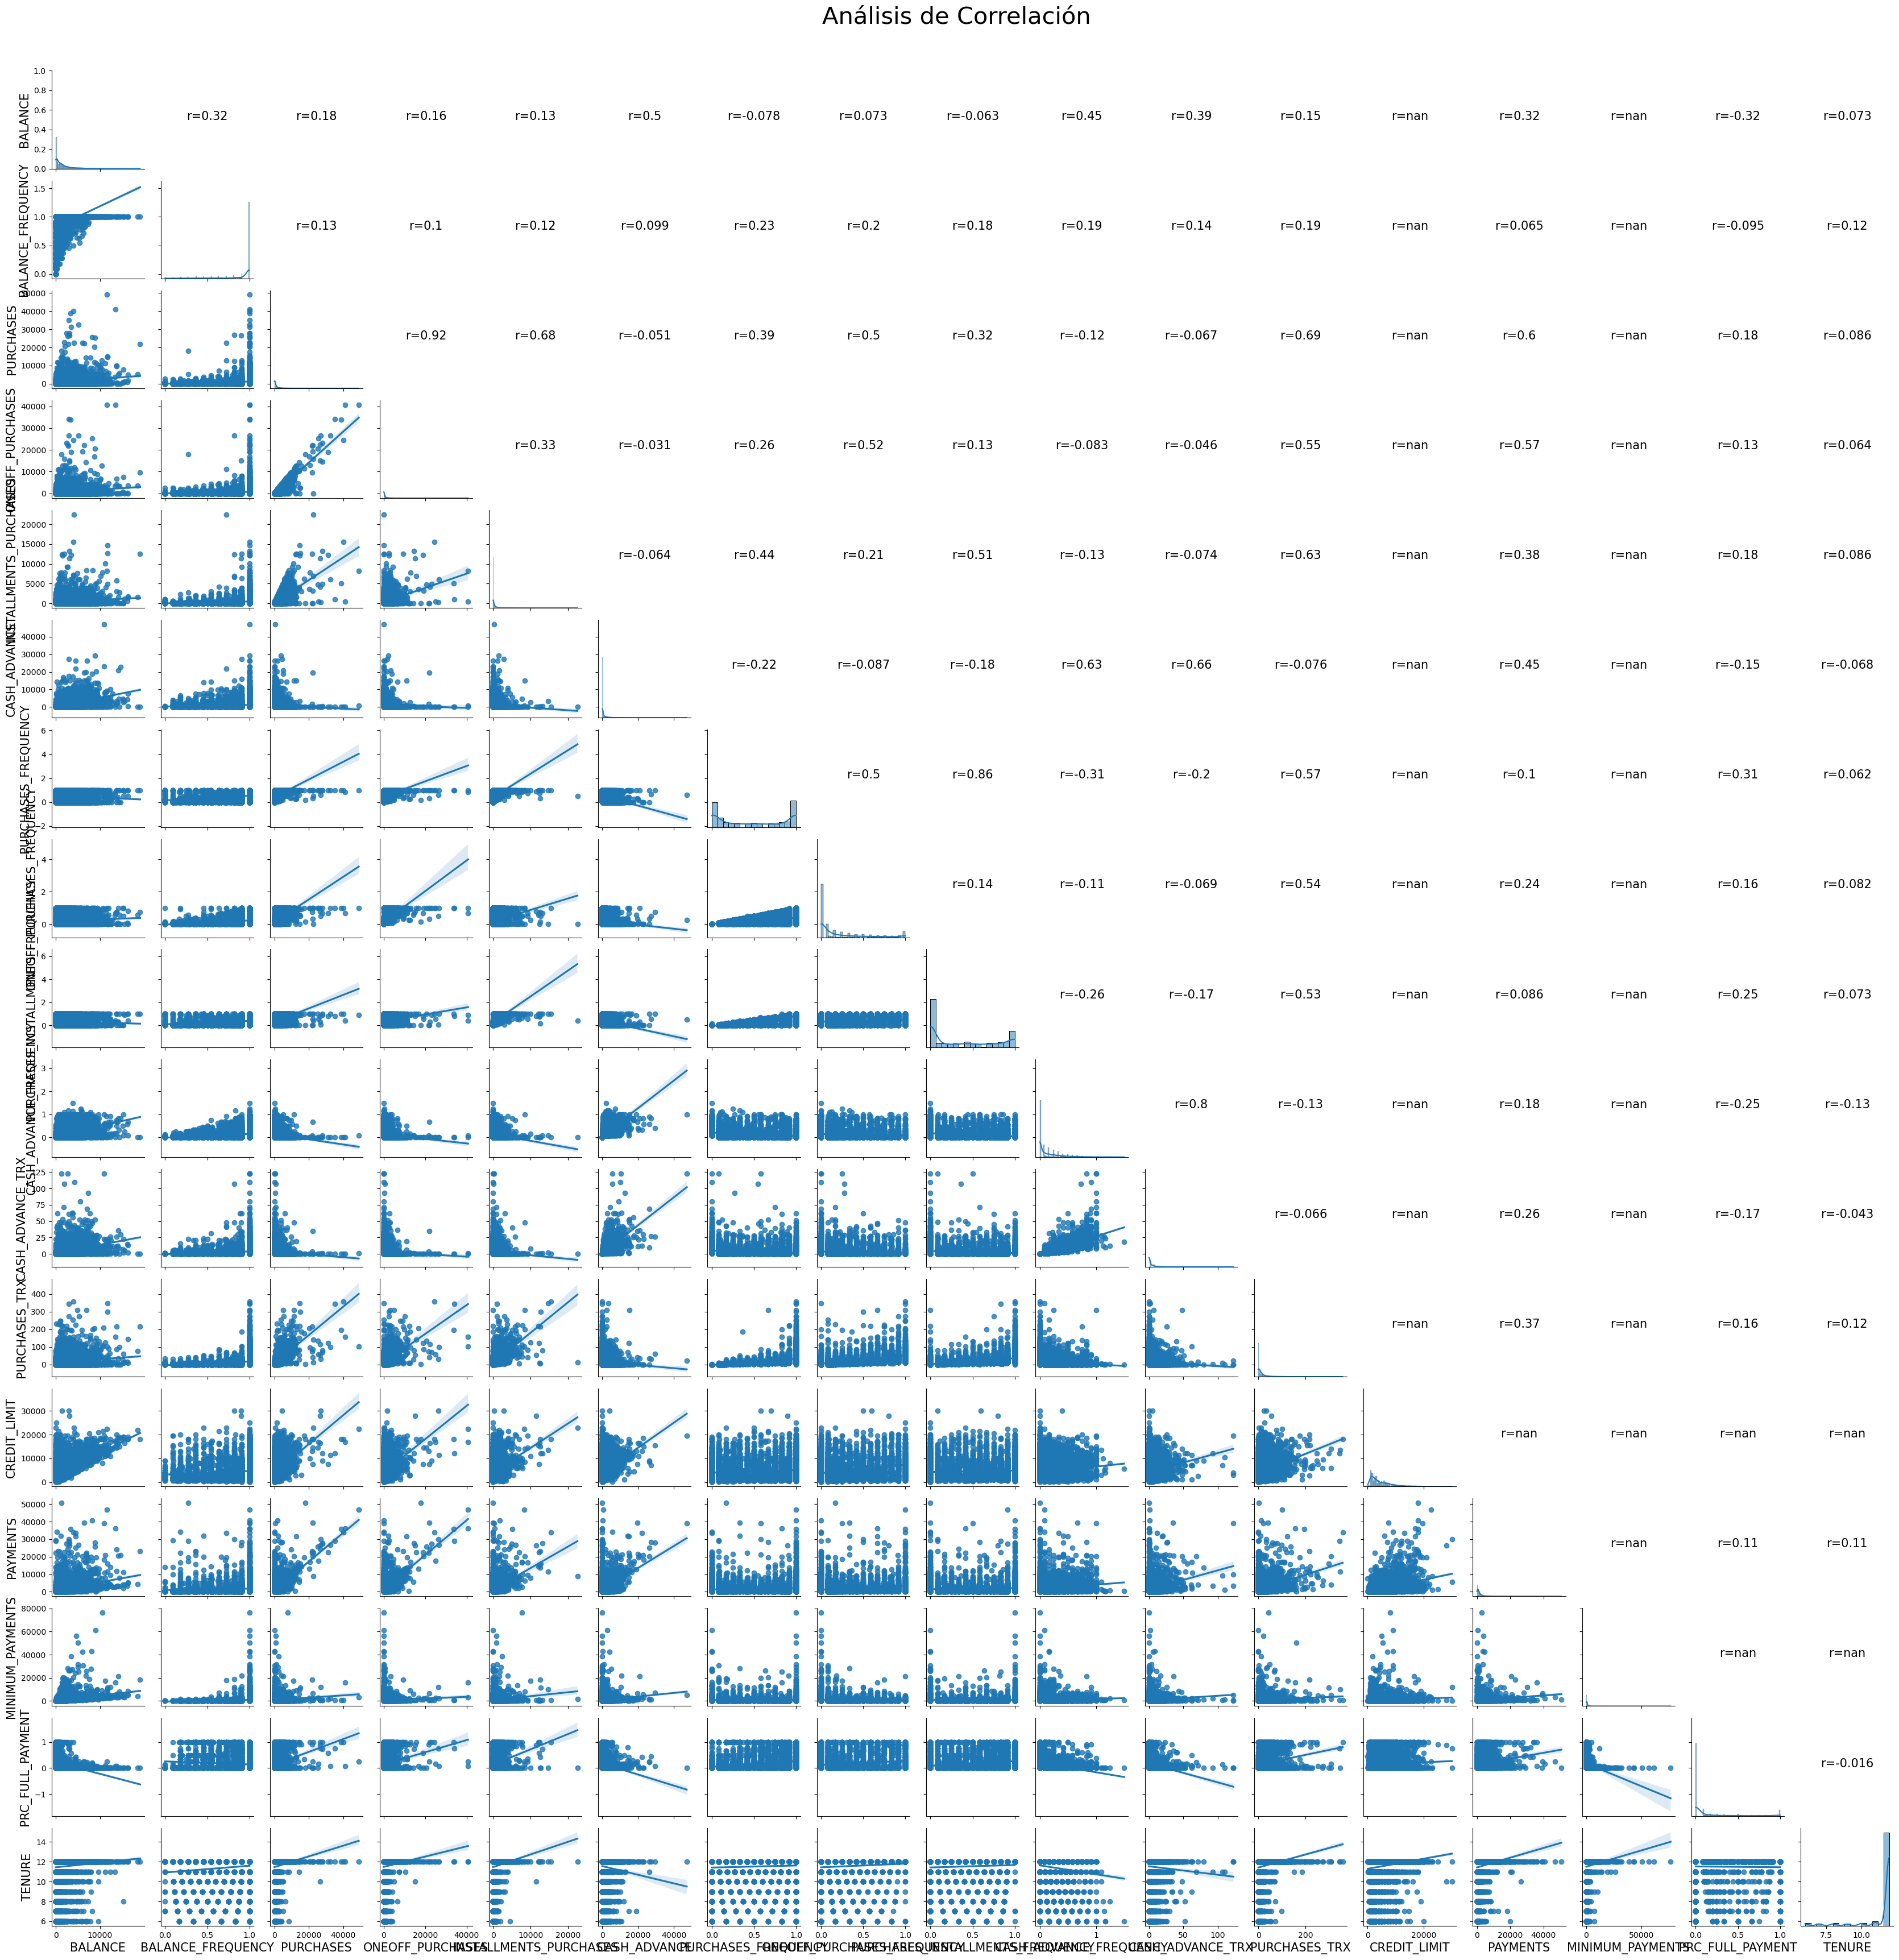

In [86]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rcParams['axes.labelsize'] = 15

g = sns.PairGrid(df2, height=2)

g.map_diag(sns.histplot, kde=True)
g.map_lower(sns.regplot)
g.map_upper(reg_coef, fontsize=20, cmap=plt.get_cmap('GnBu'))

g.fig.suptitle('Análisis de Correlación', fontsize=30, y=1.02)

plt.show()

In [87]:
df2.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [88]:
from scipy.stats import zscore
df2 = df2[cols_num].apply(zscore)

In [89]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.00,-0.00,1.00,-0.75,-0.69,-0.33,0.24,8.40
BALANCE_FREQUENCY,8950.00,0.00,1.00,-3.70,0.05,0.52,0.52,0.52
PURCHASES,8950.00,0.00,1.00,-0.47,-0.45,-0.30,0.05,22.48
ONEOFF_PURCHASES,8950.00,-0.00,1.00,-0.36,-0.36,-0.33,-0.01,24.20
INSTALLMENTS_PURCHASES,8950.00,0.00,1.00,-0.45,-0.45,-0.36,0.06,24.43
CASH_ADVANCE,8950.00,-0.00,1.00,-0.47,-0.47,-0.47,0.06,22.01
PURCHASES_FREQUENCY,8950.00,0.00,1.00,-1.22,-1.01,0.02,1.06,1.27
ONEOFF_PURCHASES_FREQUENCY,8950.00,0.00,1.00,-0.68,-0.68,-0.40,0.33,2.67
PURCHASES_INSTALLMENTS_FREQUENCY,8950.00,0.00,1.00,-0.92,-0.92,-0.50,0.97,1.60
CASH_ADVANCE_FREQUENCY,8950.00,-0.00,1.00,-0.68,-0.68,-0.68,0.44,6.82


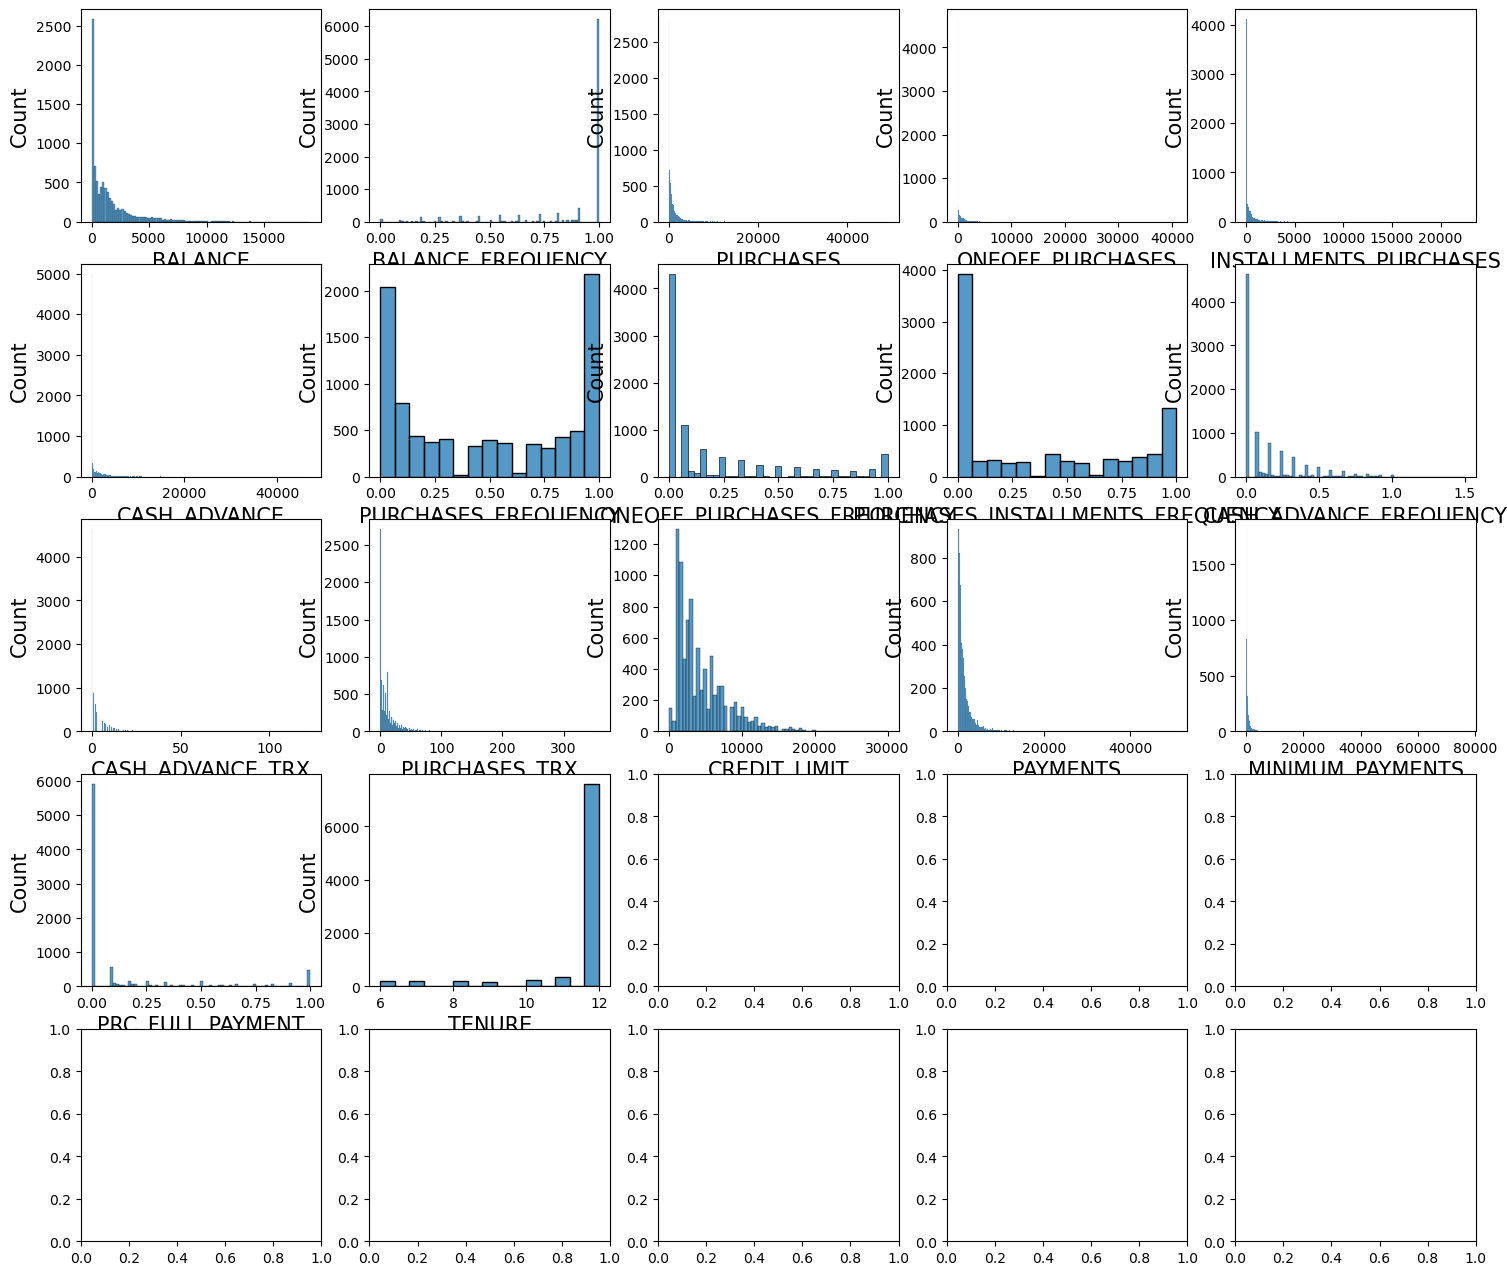

In [90]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//5,i%5],kde=False)

# Modelo de Clustering K-Means

In [105]:
df2.sample()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
7545,936.37,1.00,158.45,158.45,0.00,0.00,0.25,0.25,0.00,0.00,0,3,1700.00,160.70,443.54,0.00,12


In [ ]:
df2=df2.drop('CUST_ID',axis=1)

In [108]:
df2=df2.dropna()

Text(0.5, 1.0, 'Resultados KMeans')

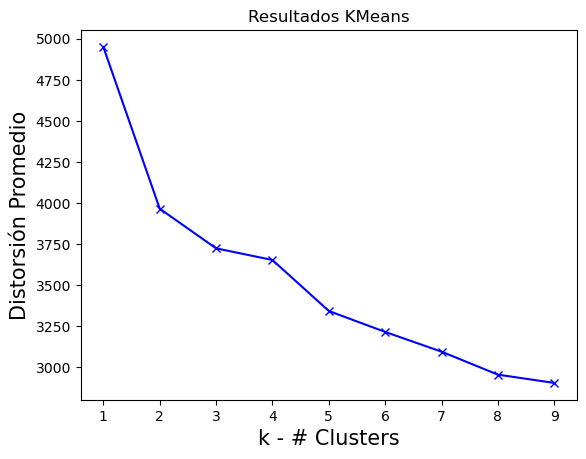

In [110]:
from scipy.spatial.distance import cdist
clusters = range(1,10)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(df2)
    prediction = model.predict(df2)
    meanDistortions.append(sum(np.min(cdist(df2,model.cluster_centers_,'euclidean'),axis=1))/df2.shape[0])

plt.plot(clusters,meanDistortions,'bx-')
plt.xlabel('k - # Clusters')
plt.ylabel('Distorsión Promedio')
plt.title('Resultados KMeans')


In [111]:
prediction

array([0, 8, 3, ..., 0, 0, 0], dtype=int32)

In [112]:
kmeans =  KMeans(n_clusters=3, n_init = 15, random_state=1)
kmeans.fit(df2)

KMeans(n_clusters=3, n_init=15, random_state=1)

In [113]:
prediction

array([0, 8, 3, ..., 0, 0, 0], dtype=int32)

In [ ]:
kmeans = KMeans(n_clusters=3,n_init=15,random_state=1)
kmeans.fit(df2)

KMeans(n_clusters=3, n_init=15, random_state=1)

In [114]:
centroids = kmeans.cluster_centers_
centroids

array([[4.87916214e+03, 9.17611326e-01, 1.08536936e+04, 7.65950163e+03,
        3.19436248e+03, 5.19215982e+03, 7.57564000e-01, 6.03537062e-01,
        6.08805682e-01, 2.28296233e-01, 9.27131783e+00, 8.68604651e+01,
        1.24848837e+04, 1.80309572e+04, 2.52779839e+03, 3.37066930e-01,
        1.18372093e+01],
       [8.81480399e+02, 8.76420436e-01, 6.22436620e+02, 3.23163177e+02,
        2.99582954e+02, 5.02024330e+02, 4.74368635e-01, 1.58352379e-01,
        3.56765199e-01, 1.08715102e-01, 2.29987294e+00, 1.09626747e+01,
        2.76931760e+03, 1.03821911e+03, 5.73070513e+02, 1.64610694e-01,
        1.14569568e+01],
       [3.45950505e+03, 9.46724692e-01, 1.59957463e+03, 9.95575645e+02,
        6.04322800e+02, 2.15068567e+03, 5.42336193e-01, 3.18129818e-01,
        3.89146486e-01, 2.14576848e-01, 5.85391226e+00, 2.24337404e+01,
        9.04866782e+03, 2.96161549e+03, 1.59656244e+03, 1.33819784e-01,
        1.17372230e+01]])

In [115]:
centroid_df = pd.DataFrame(centroids,columns=list(df2))
centroid_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,4879.16,0.92,10853.69,7659.50,3194.36,5192.16,0.76,0.60,0.61,0.23,9.27,86.86,12484.88,18030.96,2527.80,0.34,11.84
1,881.48,0.88,622.44,323.16,299.58,502.02,0.47,0.16,0.36,0.11,2.30,10.96,2769.32,1038.22,573.07,0.16,11.46
2,3459.51,0.95,1599.57,995.58,604.32,2150.69,0.54,0.32,0.39,0.21,5.85,22.43,9048.67,2961.62,1596.56,0.13,11.74


In [116]:
df_labels = pd.DataFrame(kmeans.labels_,columns=list(['labels']))
df_labels['labels'] = df_labels['labels'].astype('category')

In [117]:
df_labeled = df2.join(df_labels)

In [118]:
df_labeled.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE', 'labels'],
      dtype='object')

In [119]:
df_labeled.head(20)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,labels
0,40.90,0.82,95.40,0.00,95.40,0.00,0.17,0.00,0.08,0.00,0,2,1000.00,201.80,139.51,0.00,12,1
1,3202.47,0.91,0.00,0.00,0.00,6442.95,0.00,0.00,0.00,0.25,4,0,7000.00,4103.03,1072.34,0.22,12,2
2,2495.15,1.00,773.17,773.17,0.00,0.00,1.00,1.00,0.00,0.00,0,12,7500.00,622.07,627.28,0.00,12,2
4,817.71,1.00,16.00,16.00,0.00,0.00,0.08,0.08,0.00,0.00,0,1,1200.00,678.33,244.79,0.00,12,1
5,1809.83,1.00,1333.28,0.00,1333.28,0.00,0.67,0.00,0.58,0.00,0,8,1800.00,1400.06,2407.25,0.00,12,2
6,627.26,1.00,7091.01,6402.63,688.38,0.00,1.00,1.00,1.00,0.00,0,64,13500.00,6354.31,198.07,1.00,12,1
7,1823.65,1.00,436.20,0.00,436.20,0.00,1.00,0.00,1.00,0.00,0,12,2300.00,679.07,532.03,0.00,12,1
8,1014.93,1.00,861.49,661.49,200.00,0.00,0.33,0.08,0.25,0.00,0,5,7000.00,688.28,311.96,0.00,12,2
9,152.23,0.55,1281.60,1281.60,0.00,0.00,0.17,0.17,0.00,0.00,0,3,11000.00,1164.77,100.30,0.00,12,1
10,1293.12,1.00,920.12,0.00,920.12,0.00,1.00,0.00,1.00,0.00,0,12,1200.00,1083.30,2172.70,0.00,12,1


In [120]:
df_labeled['labels'].value_counts()

labels
1    6078
2    2136
0     125
Name: count, dtype: int64

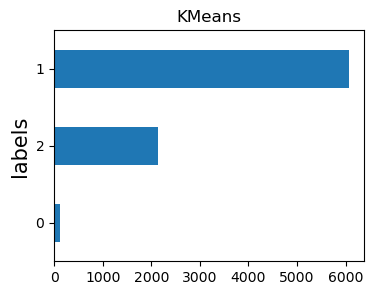

In [121]:
fig, ax = plt.subplots(figsize=(4,3))

pd.value_counts(df_labeled['labels']) \
    .sort_values(ascending=True) \
    .plot(kind='barh', ax=ax)

ax.set_title('KMeans')
plt.show()

Text(0.5, 0.98, 'Configuración de Clusters por Variable (KMeans)')

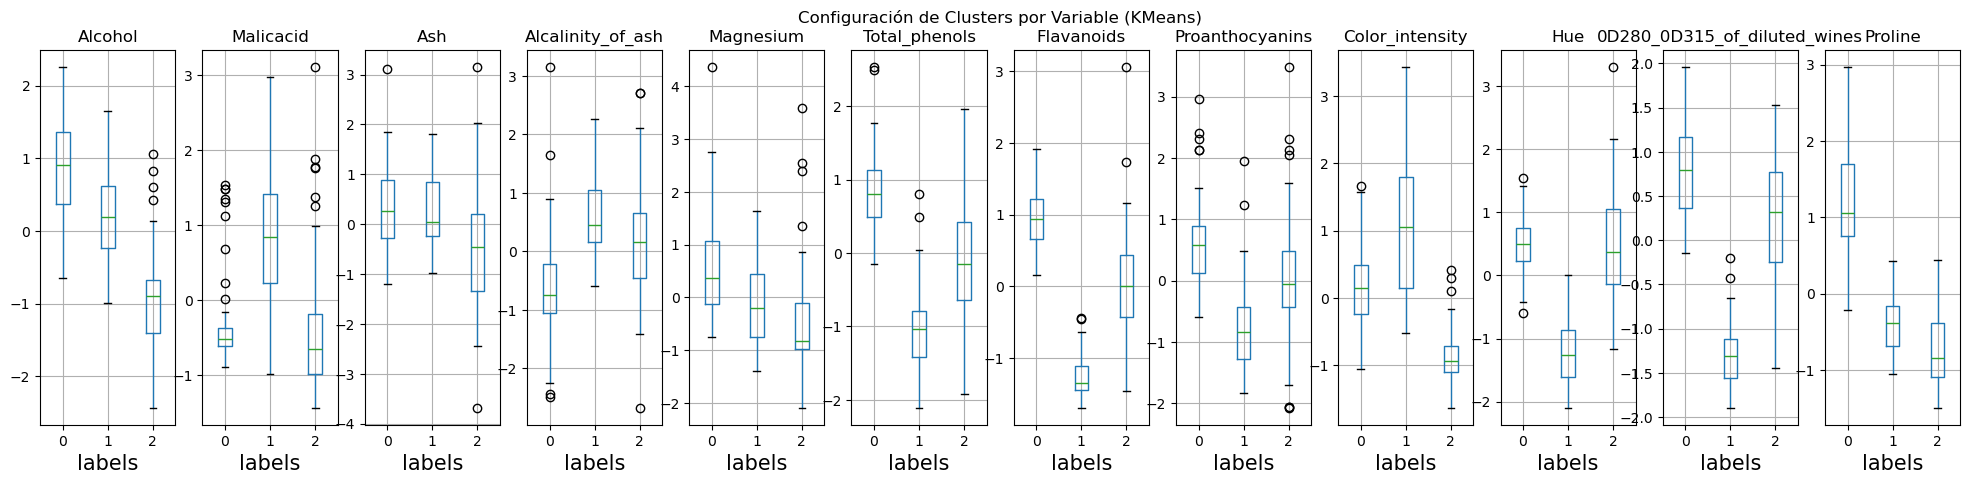

In [ ]:
fig, ax = plt.subplots(1,12, figsize=(24,5))
df_labeled.boxplot('Alcohol','labels',ax=ax[0])
df_labeled.boxplot('Malicacid','labels',ax=ax[1])
df_labeled.boxplot('Ash','labels',ax=ax[2])
df_labeled.boxplot('Alcalinity_of_ash','labels',ax=ax[3])
df_labeled.boxplot('Magnesium','labels',ax=ax[4])
df_labeled.boxplot('Total_phenols','labels',ax=ax[5])
df_labeled.boxplot('Flavanoids','labels',ax=ax[6])
df_labeled.boxplot('Proanthocyanins','labels',ax=ax[7])
df_labeled.boxplot('Color_intensity','labels',ax=ax[8])
df_labeled.boxplot('Hue','labels',ax=ax[9])
df_labeled.boxplot('0D280_0D315_of_diluted_wines','labels',ax=ax[10])
df_labeled.boxplot('Proline','labels',ax=ax[11])
fig.suptitle('Configuración de Clusters por Variable (KMeans)')

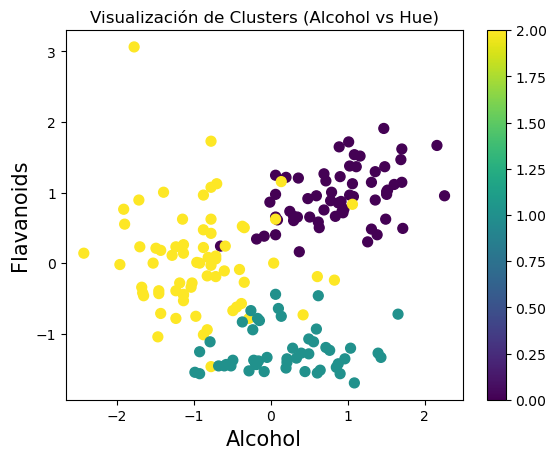

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['Alcohol'],df_labeled['Flavanoids'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (Alcohol vs Hue)')
ax.set_xlabel('Alcohol')
ax.set_ylabel('Flavanoids')
plt.colorbar(scatter)

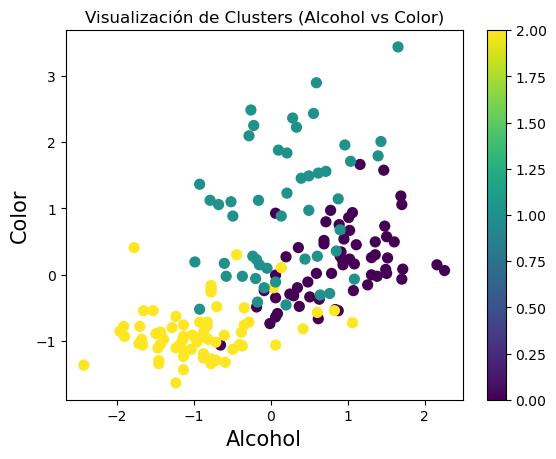

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['Alcohol'],df_labeled['Color_intensity'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (Alcohol vs Color)')
ax.set_xlabel('Alcohol')
ax.set_ylabel('Color')
plt.colorbar(scatter)

# Hierarchical Clustering


In [122]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z =  linkage(df2, 'average',metric='euclidean')
Z.shape

(8635, 4)

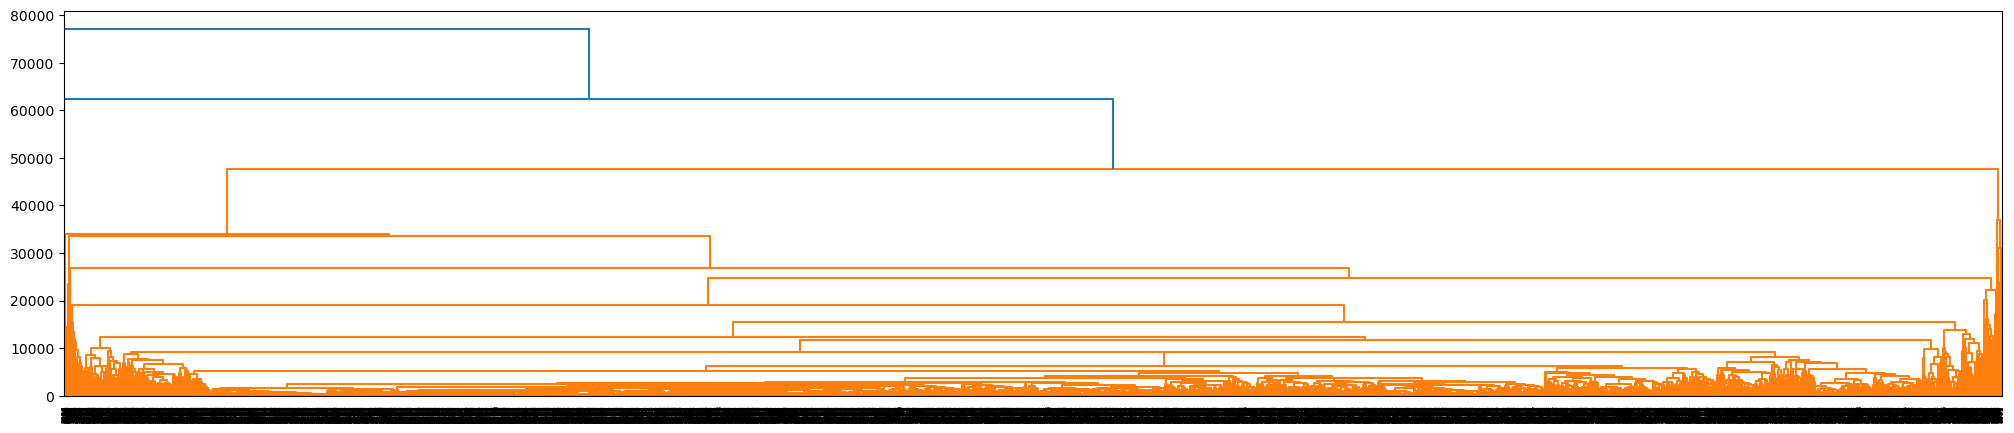

In [123]:
plt.figure(figsize=(25,5))
dendrogram(Z)
plt.show()

In [124]:
c, coph_dists = cophenet(Z,pdist(df2))
print('Cophenetic Coefficient:', format(c,'.4f'))

Cophenetic Coefficient: 0.9144


In [125]:
sil_df = pd.DataFrame({},columns=['Model','n_clusters','score'],index=None)

In [126]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for n_clusters in range(2, 10):
    clusterer = KMeans(n_clusters=n_clusters, random_state=1, n_init='auto')
    labels = clusterer.fit_predict(df2)

    score = silhouette_score(df2, labels)

    results.append({
        'Model': 'KMeans',
        'n_clusters': n_clusters,
        'score': score
    })

sil_df = pd.DataFrame(results)

Text(0.5, 1.0, 'Silhouette Score')

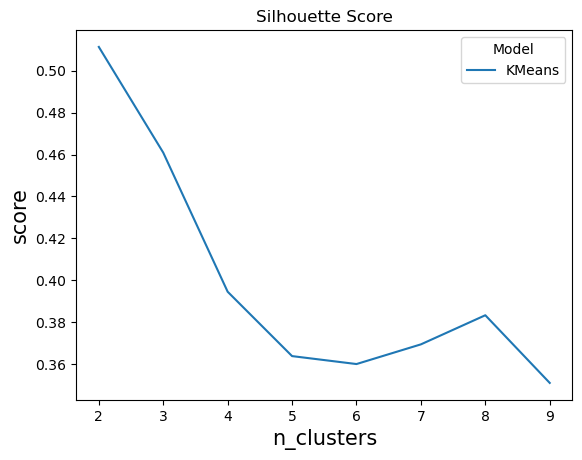

In [127]:
sns.lineplot(data = sil_df, x='n_clusters', y='score', hue='Model', style='Model', ci=None).set_title('Silhouette Score')